# drivebuddyAI — Pav Bhaji Post Classification from Instagram Metadata

**Author:** Sarthik Khanna · **Contact:** sarthikkhanna28@gmail.com

---

## The problem, stated precisely

We are given ~1,500 Instagram posts that all carry `#pavbhaji` somewhere in their
metadata. For 452 of them the accompanying image has been hand-labelled:

| label | meaning | count |
|---|---|---|
| `1` | the image **is** pav bhaji | 183 |
| `0` | the image is **not** pav bhaji | 269 |

The task is to predict that label **without looking at a single pixel** — using
only the post's caption, hashtags and metadata.

## Why this is not trivial

Every post is tagged `#pavbhaji`, so the obvious feature — "does the post mention
pav bhaji?" — is almost constant. The real question is subtler:

> **Is `#pavbhaji` describing this picture, or is it just one of thirty hashtags
> a food blogger sprayed on for reach?**

That reframing drives the whole solution. A negative post typically looks like
this — the prose is about *chicken tikka*, and `#pavbhaji` is buried in a
hashtag wall:

```
Chicken Tikka 😍😋
.
.
Follow @dilli_ki_teekhi_mirchi
#dillifoodjunkie #pasta #food #pavbhaji #chicken #butterchicken ...
```

while a positive post names the dish up front, in the prose:

```
Pav Bhaji at Mazgaon Khaugalli
Devoured this piping hot Pav Bhaji at the little known Mazgaon Khaugalli...
#pavbhaji #streetfood #mumbai
```

So **where** a word appears matters more than **whether** it appears. That is the
central modelling idea of this notebook.

## Notebook map

1. Load the data and recover labels from the image folders
2. Exploratory analysis of captions, hashtags and engagement
3. **Feature inventory and relevance** (deliverable #1)
4. Feature engineering
5. Model comparison under two cross-validation schemes
6. Feature-block ablation
7. Final model, held-out evaluation and error analysis
8. Scoring the 1,043 unlabelled posts
9. Limitations and what I would do next

## 1 · Setup

In [1]:
import json, os, re, sys, unicodedata, warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 130)
pd.set_option("display.max_colwidth", 90)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160, "figure.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10,
})
C1, C0, CA = "#D1495B", "#30638E", "#8A8A8A"   # positive / negative / accent

FIGDIR = "figures"
os.makedirs(FIGDIR, exist_ok=True)

def save(fig, name):
    fig.tight_layout()
    fig.savefig(os.path.join(FIGDIR, name), bbox_inches="tight")
    return fig

# Locate the dataset folder (works whether the notebook sits next to `dataset/`
# or one level above it).
CANDIDATES = ["dataset", "./dataset", "../dataset", "data/dataset"]
DATA_DIR = next((p for p in CANDIDATES
                 if os.path.exists(os.path.join(p, "pavbhaji.json"))), None)
assert DATA_DIR, "Could not find pavbhaji.json - set DATA_DIR manually."
print("Dataset directory:", os.path.abspath(DATA_DIR))
print("sklearn", __import__("sklearn").__version__, "| pandas", pd.__version__)

Dataset directory: C:\pavbaji\dataset


sklearn 1.8.0 | pandas 2.3.3


## 2 · Loading the data and recovering the labels

`pavbhaji.json` is a list of 1,500 post objects. It contains **no label field** —
the ground truth lives in the folder an image was filed under (`images/1` vs
`images/0`).

The join key is the image file name. Instagram's `display_url` looks like

```
https://instagram.f...fbcdn.net/vp/<hash>/<exp>/t51.2885-15/e35/37599530_291077411445016_...n.jpg
```

and its last path segment is exactly the file name on disk. Taking the basename
of `display_url` (falling back to `thumbnail_src`) recovers **452/452** labels
with zero misses.

In [2]:
def basename(url: str) -> str:
    return os.path.basename((url or "").split("?")[0])


def load_dataset(data_dir: str) -> pd.DataFrame:
    """Flatten pavbhaji.json into a DataFrame and attach labels from image folders."""
    with open(os.path.join(data_dir, "pavbhaji.json"), encoding="utf-8") as fh:
        posts = json.load(fh)

    label_by_file = {}
    for lbl in (0, 1):
        folder = os.path.join(data_dir, "images", str(lbl))
        if os.path.isdir(folder):
            for fn in os.listdir(folder):
                if fn.lower().endswith((".jpg", ".jpeg", ".png")):
                    label_by_file[fn] = lbl

    records, seen = [], set()
    for p in posts:
        pid = p.get("id")
        if pid in seen:                      # the JSON repeats 5 posts verbatim
            continue
        seen.add(pid)

        fname = basename(p.get("display_url"))
        if fname not in label_by_file:
            fname = basename(p.get("thumbnail_src"))

        edges = (p.get("edge_media_to_caption") or {}).get("edges") or []
        dims = p.get("dimensions") or {}
        loc = p.get("location") or {}

        records.append(dict(
            id=pid,
            shortcode=p.get("shortcode"),
            image_file=fname,
            label=label_by_file.get(fname, np.nan),
            caption=edges[0]["node"]["text"] if edges else "",
            tags=p.get("tags") or [],
            likes=(p.get("edge_liked_by") or {}).get("count", 0) or 0,
            comments=(p.get("edge_media_to_comment") or {}).get("count", 0) or 0,
            is_video=bool(p.get("is_video")),
            comments_disabled=bool(p.get("comments_disabled")),
            owner_id=(p.get("owner") or {}).get("id"),
            width=dims.get("width") or 0,
            height=dims.get("height") or 0,
            timestamp=p.get("taken_at_timestamp") or 0,
            has_location=int(bool(loc)),
            location_name=(loc.get("name") if isinstance(loc, dict) else "") or "",
        ))
    return pd.DataFrame.from_records(records)


raw = load_dataset(DATA_DIR)
n_img = sum(len(os.listdir(os.path.join(DATA_DIR, "images", d))) for d in "01")

print(f"posts in JSON (deduplicated) : {len(raw)}")
print(f"labelled images on disk      : {n_img}")
print(f"labels successfully joined   : {int(raw['label'].notna().sum())}")
print(f"unlabelled posts (hold-back) : {int(raw['label'].isna().sum())}")
print()
print(raw["label"].value_counts(dropna=False).rename(
    {1.0: "1 - pav bhaji", 0.0: "0 - not pav bhaji"}).to_string())

posts in JSON (deduplicated) : 1495
labelled images on disk      : 452
labels successfully joined   : 452
unlabelled posts (hold-back) : 1043

label
NaN                  1043
0 - not pav bhaji     269
1 - pav bhaji         183


In [3]:
raw.drop(columns=["caption"]).head(3)

,id,shortcode,image_file,label,tags,likes,comments,is_video,comments_disabled,owner_id,width,height,timestamp,has_location,location_name
0,1834712933156555738,Bl2NbElnIva,37599530_291077411445016_3382263118984904704_n.jpg,NaN,"[vadapav, foodgram, foodphotography, foodblogger, mumbai, foodaholic, foodie, foodcoma...",3797,52,True,False,1919686029,640,734,1532934873,0,
1,1826000656302706137,BlXQewejY3Z,36848355_187489742110497_7922878806031859712_n.jpg,NaN,"[healthyfood, sokolkata, mumbaifoodie, faridabad, indianfoodbloggers, incredibile, veg...",12041,325,True,False,1445587278,750,750,1531897016,1,Faridabad
2,1849962218902145720,BmsYtYpjkq4,38618276_2089245347991843_6362789531271299072_n.jpg,NaN,"[foodphotography, mumbaipeople, vascom, delhiboy, pull, instashot, streetfoodchandigar...",3544,18,True,False,4759392841,640,800,1534752790,1,"Chandigarh, India"


## 3 · Exploratory analysis

Before engineering anything, a look at what separates the two classes.

In [4]:
labelled = raw[raw["label"].notna()].reset_index(drop=True).copy()
labelled["label"] = labelled["label"].astype(int)
y_all = labelled["label"].values

n1, n0 = int((y_all == 1).sum()), int((y_all == 0).sum())
majority = max(n1, n0) / len(y_all)
print(f"class balance: {n1} positive / {n0} negative "
      f"({n1/len(y_all):.1%} positive)")
print(f"majority-class baseline accuracy: {majority:.3f}   <- everything must beat this")

class balance: 183 positive / 269 negative (40.5% positive)
majority-class baseline accuracy: 0.595   <- everything must beat this


In [5]:
HASHTAG_RE = re.compile(r"#([^\s#@]+)")
MENTION_RE = re.compile(r"@([A-Za-z0-9._]+)")


def split_caption(caption: str):
    """Separate the prose the author wrote from the hashtag wall and @mentions."""
    caption = caption or ""
    hashtags = [h.lower() for h in HASHTAG_RE.findall(caption)]
    mentions = [m.lower() for m in MENTION_RE.findall(caption)]
    body = MENTION_RE.sub(" ", HASHTAG_RE.sub(" ", caption))
    body = re.sub(r"^[\s.•➖〰~\-_=+*]+$", " ", body, flags=re.M)
    return re.sub(r"\s+", " ", body).strip(), hashtags, mentions


_parsed = labelled["caption"].map(split_caption)
labelled["body"] = [b for b, _, _ in _parsed]
labelled["caption_hashtags"] = [h for _, h, _ in _parsed]

summary = labelled.assign(
    n_hashtags=labelled["caption_hashtags"].map(len),
    caption_len=labelled["caption"].str.len(),
    body_len=labelled["body"].str.len(),
).groupby("label")[["n_hashtags", "caption_len", "body_len", "likes", "comments"]].median()
summary.index = ["0 - not pav bhaji", "1 - pav bhaji"]
print("Median values by class:")
summary

Median values by class:


,n_hashtags,caption_len,body_len,likes,comments
0 - not pav bhaji,26.0,404.0,92.0,57.0,1.0
1 - pav bhaji,19.0,350.0,92.0,49.0,2.0


Two things already stand out: negative posts carry **more hashtags** and **longer
captions**. That is the signature of the reach-farming roundup post that tags a
dozen dishes at once.

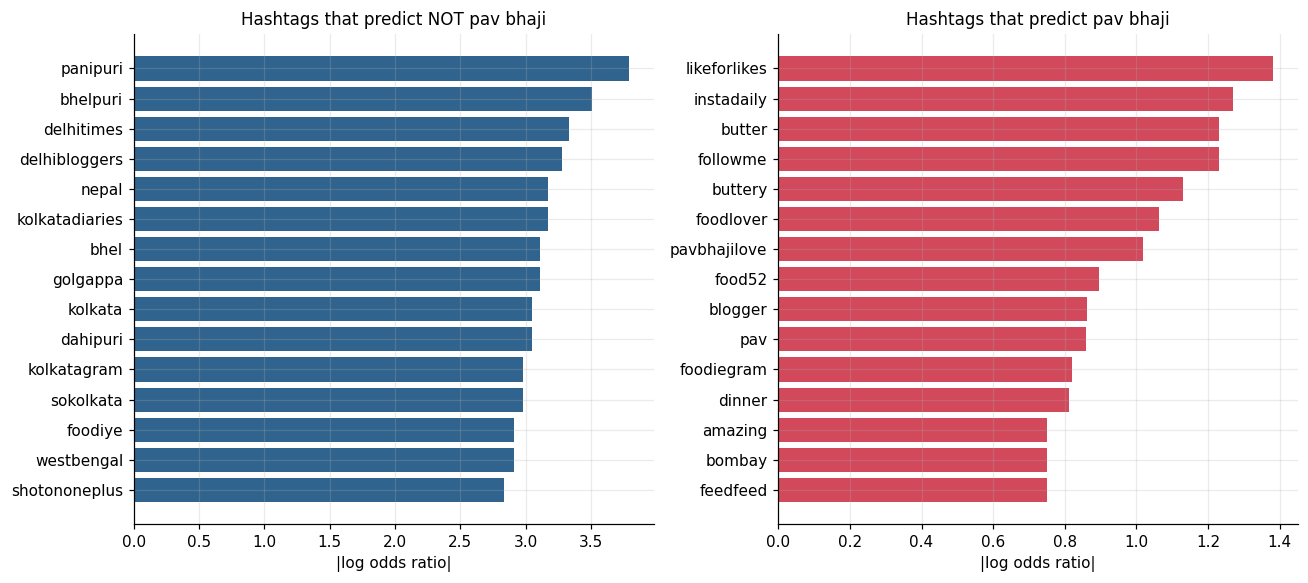

In [6]:
import collections, math

tag_pos, tag_neg = collections.Counter(), collections.Counter()
for tags, lab in zip(labelled["tags"], labelled["label"]):
    for t in set(str(x).lower() for x in tags):
        (tag_pos if lab == 1 else tag_neg)[t] += 1

rows = []
for t in set(tag_pos) | set(tag_neg):
    a, b = tag_pos[t], tag_neg[t]
    if a + b < 10:                     # ignore rare tags
        continue
    lo = math.log(((a + 0.5) / (n1 + 1)) / ((b + 0.5) / (n0 + 1)))
    rows.append((t, a, b, lo))

tag_df = (pd.DataFrame(rows, columns=["hashtag", "in_pos", "in_neg", "log_odds"])
          .sort_values("log_odds"))

fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))
for ax, sub, colour, title in [
    (axes[0], tag_df.head(15), C0, "Hashtags that predict NOT pav bhaji"),
    (axes[1], tag_df.tail(15).iloc[::-1], C1, "Hashtags that predict pav bhaji"),
]:
    ax.barh(sub["hashtag"], sub["log_odds"].abs(), color=colour)
    ax.invert_yaxis(); ax.set_title(title, fontsize=11)
    ax.set_xlabel("|log odds ratio|")
save(fig, "01_discriminative_hashtags.png"); plt.show()

The negative side is a **menu of other dishes** — `panipuri`, `bhelpuri`,
`golgappa`, `dahipuri`, `masaladosa`, `gulabjamun` — appearing with a log-odds
that is effectively "-infinity": these tags occur *only* on negatives. The
positive side is far weaker: generic enthusiasm (`homemade`, `foodlover`,
`butter`, `pav`).

That asymmetry is the exploitable structure. **Evidence against the dish is much
sharper than evidence for it**, because a post about golgappa is definitively not
a post about pav bhaji, whereas `#foodporn` means nothing either way.

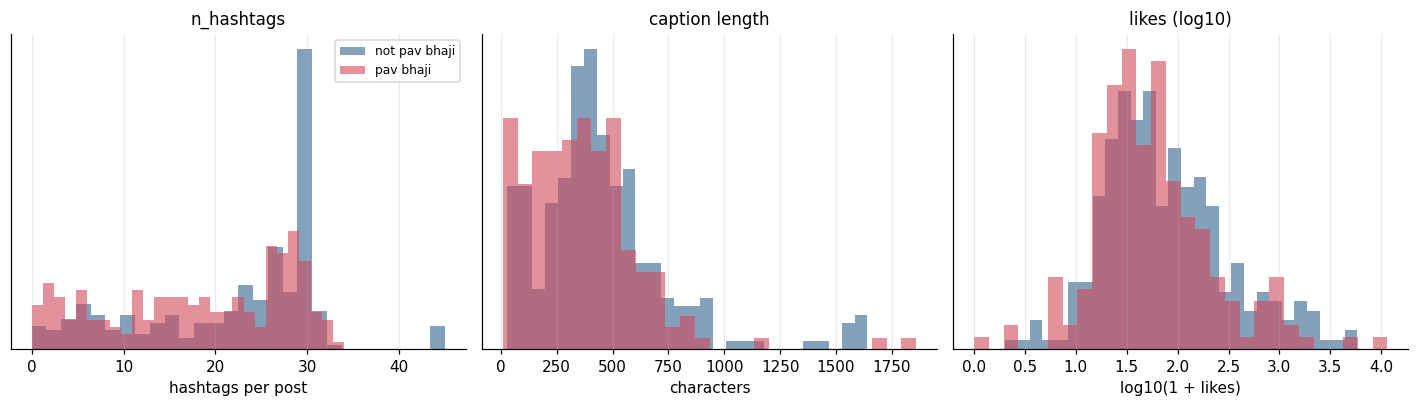

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
specs = [("n_hashtags", "hashtags per post", labelled["caption_hashtags"].map(len)),
         ("caption length", "characters", labelled["caption"].str.len()),
         ("likes (log10)", "log10(1 + likes)", np.log10(1 + labelled["likes"]))]
for ax, (title, xlabel, series) in zip(axes, specs):
    for lab, colour, name in [(0, C0, "not pav bhaji"), (1, C1, "pav bhaji")]:
        ax.hist(series[labelled["label"] == lab], bins=28, alpha=0.6,
                color=colour, label=name, density=True)
    ax.set_title(title, fontsize=11); ax.set_xlabel(xlabel); ax.set_yticks([])
axes[0].legend(fontsize=8)
save(fig, "02_distributions.png"); plt.show()

In [8]:
owners = labelled.groupby("owner_id")["label"].agg(["size", "nunique"])
print(f"distinct accounts            : {len(owners)}")
print(f"posts from repeat accounts   : {int(owners.loc[owners['size'] > 1, 'size'].sum())}")
print(f"accounts posting BOTH classes: {int((owners['nunique'] > 1).sum())}")
print()
print("A few accounts appear several times, so a plain random split can leak an")
print("author's writing style from train into test. Section 6 therefore reports")
print("owner-grouped cross-validation alongside the standard stratified one.")

distinct accounts            : 370
posts from repeat accounts   : 112
accounts posting BOTH classes: 8

A few accounts appear several times, so a plain random split can leak an
author's writing style from train into test. Section 6 therefore reports
owner-grouped cross-validation alongside the standard stratified one.


## 4 · Feature inventory and relevance

**This section is deliverable #1: "list down features and their relevance".**

Every field in `pavbhaji.json`, what it can contribute, and the verdict.

### 4.1 Fields available in the metadata

| JSON field | Type | Signal for this task | Used? |
|---|---|---|---|
| `edge_media_to_caption.edges[0].node.text` | free text | **The primary signal.** Contains both the author's prose and the hashtag wall. | ✅ core |
| `tags` | list of strings | Topic hashtags. Rival-dish tags are near-deterministic negatives. | ✅ core |
| `edge_liked_by.count` / `edge_media_preview_like.count` | int | Weak popularity proxy. Identical to each other — one is dropped. | ✅ weak |
| `edge_media_to_comment.count` | int | Weak engagement proxy. No comment *text* is provided. | ✅ weak |
| `dimensions.width` / `.height` | int | Aspect ratio. Feed-cropped 1:1 vs 4:5 portrait differs slightly by post type. | ✅ weak |
| `taken_at_timestamp` | unix ts | Hour/day-of-week — meal-time posting rhythm. | ✅ weak |
| `location` | object / null | Present on 60% of posts. Venue names like *"Sardar Pav Bhaji"* are direct evidence. | ✅ weak |
| `is_video` | bool | **Constant `False`** across all 452 labelled posts — zero variance. | ❌ |
| `video_view_count` | int | Always 0 for labelled posts (they are all stills). | ❌ |
| `comments_disabled` | bool | `True` on 1 of 452 posts. Effectively constant. | ❌ |
| `owner.id` | string | Predictive but **memorises the account, not the dish** — a leakage trap. | ❌ (used only to *group* CV folds) |
| `display_url`, `thumbnail_src`, `urls`, `thumbnail_resources` | URLs | CDN links. Used **only** to join the label; no signal. | ❌ |
| `id`, `shortcode` | string | Identifiers. No signal. | ❌ |

Explicitly rejected: **`owner.id`**. It cross-validates well because several
accounts post repeatedly, but it would generalise to nothing — a model that has
learned "account 4085064959 posts pav bhaji" is useless on a new account. It is
used as the *grouping variable* for leakage-aware validation instead.

### 4.2 Derived features and why each should matter

The raw fields above are not the model's features. These are — grouped by the
hypothesis each encodes.

#### A. Where is the dish named? *(the core idea)*

| Feature | Definition | Why it should work |
|---|---|---|
| `pb_in_body` | pav bhaji named in the prose, hashtags stripped | If the author *wrote* about it, the picture is probably it |
| `pb_in_lead` | named in the first 120 characters | Instagram captions front-load the subject |
| `pb_first_pos` | normalised position of the first mention (0 = start, 1 = absent/buried) | A mention at char 800 inside a tag wall is worth far less than one at char 3 |
| `pb_tag_rank` | position of `#pavbhaji` among the caption's hashtags | Authors tag the subject first, then pad |
| `pb_tag_top3` | `#pavbhaji` among the first 3 hashtags | Hard version of the above |
| `pb_in_tags`, `pb_body_count`, `pb_caption_count`, `pb_support` | presence / repetition counts, plus support words (`bhaji`, `ladi pav`, `amul butter`) | Repetition = emphasis |

#### B. Is a *different* dish the subject? *(the sharpest negative evidence)*

| Feature | Definition | Why it should work |
|---|---|---|
| `first_dish_caption` | Which dish name appears **first** — pav bhaji (1), a rival (0), none (0.5) | The subject of a caption is the first food word in it. This is the single strongest feature in the study |
| `first_dish_body`, `first_dish_lead` | same test on the prose / on the lead | Scoped variants |
| `comp_in_body`, `comp_in_lead` | a rival dish named in the prose / lead | "Chicken Tikka 😍" + `#pavbhaji` = negative |
| `comp_body_count`, `comp_tag_count` | how many *distinct* rival dishes are named | A post naming 6 dishes is a roundup, not a pav bhaji photo |
| `dish_purity_body`, `dish_purity_tags` | pav-bhaji mentions ÷ all dish mentions | Normalises for caption length |
| `dish_tag_density` | rival-dish tags ÷ total tags | Detects the shotgun tagger |
| `comp_tag_top3` | a rival dish among the first 3 hashtags | Hard negative |

The rival-dish lexicon holds ~130 hand-curated Indian and continental dish names.
It is written by hand rather than mined from the training labels, so it cannot
leak: it encodes prior culinary knowledge, not the answer key.

#### C. Is this a genuine food post or a reach-farming post?

| Feature | Definition | Why it should work |
|---|---|---|
| `n_tags`, `n_caption_hashtags` | hashtag volume | Negatives carry ~4 more tags at the median |
| `hashtag_char_ratio`, `body_char_ratio` | share of the caption that is hashtags vs prose | A caption that is 80% hashtags says little about its picture |
| `n_dot_lines` | count of `.`-only separator lines | The `.\n.\n.` spacer is a hallmark of the tag-wall post |
| `n_follow`, `n_mentions`, `n_spam_tags` | "Follow @x" repetitions, @mentions, `#like4like`-type tags | Engagement-bait markers |
| `is_repost` | `Repost`/`Regrann`/`PC @` present | Reposts are curation feeds — many dishes, low precision |
| `caption_len`, `body_len`, `body_words`, `n_emoji`, `n_newlines`, `upper_ratio` | shape of the text | Cheap style descriptors |

#### D. Weak contextual signal

`log_likes`, `log_comments`, `comment_rate`, `aspect`, `is_square`,
`is_portrait`, `megapixels`, `has_location`, `loc_is_pb`, `hour_sin`,
`hour_cos`, `dow`, `month`. Individually near-useless; kept because a
regulariser can discard them cheaply and one or two help at the margin.

#### E. Learned text representations

Four TF-IDF views, each answering a different question:

| View | Configuration | Question it answers |
|---|---|---|
| `body_text` | word 1–2 grams, `min_df=2`, sublinear tf | What did the author actually say? |
| `tag_text` | word unigrams over all hashtags | What topics were claimed? |
| `lead_text` | **character** 3–5 grams over the first 120 chars | Catches `paav bhaaji`, `pavbhajji`, `PavBhaji` — spelling varies enormously and word tokens miss it |
| *(evaluated, dropped)* `top_tag_text` | first 6 hashtags only | Added nothing over `tag_text` |

Character n-grams matter more than usual here: Hinglish transliteration means the
same dish is spelled a dozen ways, and hashtags glue words together
(`#butterpavbhaji`), which destroys word tokenisation.

## 5 · Building the features

In [9]:
# ---------------------------------------------------------------- lexicons
# Surface forms of the target dish. Spelling on Instagram is wildly
# inconsistent (pav/paav/pao, bhaji/bhajji/bhaaji) and hashtags glue words
# together, so matching happens on a "squashed" string with all whitespace and
# punctuation removed.
PAVBHAJI_RE = re.compile("|".join([
    r"p[ae]*[vo]+bh?[aeu]*j+i+",      # pavbhaji, paavbhaaji, paobhaji, pavbhajji
    r"bh?[a]+j+ip[ae]*[vo]",          # bhajipav
    r"masalapav",
]))

PAVBHAJI_SUPPORT = ["bhaji", "bhajji", "ladipav", "amulbutter", "butterbhaji",
                    "chowpatty", "pavbhajifondue"]

# ~130 dishes that are NOT pav bhaji. Hand-written from domain knowledge, not
# mined from the labels, so it carries no leakage.
COMPETITOR_DISHES = [
    "vadapav", "panipuri", "golgappa", "golgappe", "puchka", "phuchka",
    "bhelpuri", "bhel", "dahipuri", "sevpuri", "dahibhalla", "alootikki",
    "tikki", "rajkachori", "kachori", "samosa", "chaat", "papdichaat",
    "frankie", "misal", "misalpav", "dabeli", "sandwich", "grilledsandwich",
    "dosa", "masaladosa", "idli", "uttapam", "utappam", "sambar", "rasam",
    "appam", "pongal", "medhuvada", "vada",
    "cholebhature", "bhature", "chole", "poori", "puri", "rajma", "kadhi",
    "paneertikka", "paneerbuttermasala", "shahipaneer", "dalmakhani",
    "butterchicken", "chickentikka", "tandoorichicken", "kebab", "seekhkebab",
    "biryani", "pulao", "khichdi", "naan", "kulcha", "paratha", "roti",
    "thali", "curry",
    "poha", "upma", "sabudana", "dhokla", "khandvi", "thepla", "pakoda",
    "pakora", "breadpakoda", "maggi", "maggie", "omelette", "bhurji",
    "eggroll", "momo", "momos", "springroll", "noodles", "chowmein",
    "manchurian", "friedrice", "hakkanoodles",
    "pizza", "burger", "pasta", "fries", "frenchfries", "garlicbread",
    "shawarma", "sushi", "taco", "nachos", "hotdog",
    "jalebi", "gulabjamun", "rasmalai", "rasgulla", "halwa", "barfi",
    "laddu", "kulfi", "falooda", "icecream", "cake", "brownie", "waffle",
    "pancake", "donut", "cupcake", "croissant", "pastry", "chocolate",
    "milkshake", "lassi", "chai", "coffee", "mojito",
    "chicken", "mutton", "fish", "prawn", "egg",
]
COMPETITOR_RE = re.compile("|".join(sorted(COMPETITOR_DISHES, key=len, reverse=True)))

SPAM_TAGS = {"like4like", "likeforlike", "likeforlikes", "l4l", "f4f", "follow",
             "followme", "follow4follow", "instagood", "instadaily",
             "picoftheday", "photooftheday", "tflers", "20likes", "instalike",
             "bestoftheday", "instafollow", "likes", "tagsforlikes", "igers"}

EMOJI_RE = re.compile("[" "\U0001F300-\U0001FAFF" "\U00002600-\U000027BF"
                      "\U0001F1E6-\U0001F1FF" "\U00002B00-\U00002BFF"
                      "\U0000FE0F" "]")
LEAD_CHARS = 120

In [10]:
def strip_accents(s):
    return "".join(c for c in unicodedata.normalize("NFKD", str(s))
                   if not unicodedata.combining(c))


def squash(s):
    """'Paav  Bhaaji!' -> 'paavbhaaji'. Makes dish matching spacing-proof."""
    return re.sub(r"[^a-z0-9]+", "", strip_accents(s).lower())


def tokenise(s):
    """Lowercase, split camelCase (#PavBhaji -> pav bhaji), keep words apart."""
    s = strip_accents(s)
    s = re.sub(r"(?<=[a-z])(?=[A-Z])", " ", s)
    s = re.sub(r"[^A-Za-z0-9]+", " ", s).lower()
    return re.sub(r"\s+", " ", s).strip()


def first_match_pos(pattern, sq):
    """Normalised position (0..1) of the first match; 1.0 when absent."""
    if not sq:
        return 1.0
    m = pattern.search(sq)
    return (m.start() / len(sq)) if m else 1.0


def first_dish(sq):
    """Which dish is named FIRST: pav bhaji (1.0), a rival (0.0), none (0.5)."""
    pb, cp = PAVBHAJI_RE.search(sq), COMPETITOR_RE.search(sq)
    if pb and cp:
        return 1.0 if pb.start() <= cp.start() else 0.0
    return 1.0 if pb else (0.0 if cp else 0.5)

In [11]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    parsed = out["caption"].fillna("").map(split_caption)
    out["body"] = [b for b, _, _ in parsed]
    out["caption_hashtags"] = [h for _, h, _ in parsed]
    out["mentions"] = [m for _, _, m in parsed]
    out["all_tags"] = [list(dict.fromkeys(list(ch) + [str(t).lower() for t in tg]))
                       for ch, tg in zip(out["caption_hashtags"], out["tags"])]

    # --- text views handed to the vectorisers ---------------------------
    out["body_text"] = out["body"].map(tokenise)
    out["tag_text"] = out["all_tags"].map(lambda ts: " ".join(tokenise(t) for t in ts))
    out["lead_text"] = out["caption"].fillna("").str[:LEAD_CHARS].map(tokenise)

    # --- squashed strings used by the dish regexes ----------------------
    sq_body = out["body"].map(squash)
    sq_lead = out["caption"].fillna("").str[:LEAD_CHARS].map(squash)
    sq_cap = out["caption"].fillna("").map(squash)

    # --- A. where is the dish named? ------------------------------------
    out["pb_in_body"] = sq_body.map(lambda s: int(bool(PAVBHAJI_RE.search(s))))
    out["pb_in_lead"] = sq_lead.map(lambda s: int(bool(PAVBHAJI_RE.search(s))))
    out["pb_in_tags"] = out["all_tags"].map(
        lambda ts: int(any(PAVBHAJI_RE.search(squash(t)) for t in ts)))
    out["pb_body_count"] = sq_body.map(lambda s: len(PAVBHAJI_RE.findall(s)))
    out["pb_caption_count"] = sq_cap.map(lambda s: len(PAVBHAJI_RE.findall(s)))
    out["pb_first_pos"] = sq_cap.map(lambda s: first_match_pos(PAVBHAJI_RE, s))
    out["pb_support"] = sq_cap.map(lambda s: int(any(w in s for w in PAVBHAJI_SUPPORT)))
    out["pb_tag_rank"] = out["caption_hashtags"].map(
        lambda ts: next((i / max(len(ts), 1) for i, t in enumerate(ts)
                         if PAVBHAJI_RE.search(squash(t))), 1.0))
    out["pb_tag_top3"] = out["caption_hashtags"].map(
        lambda ts: int(any(PAVBHAJI_RE.search(squash(t)) for t in ts[:3])))

    # --- B. is a different dish the subject? -----------------------------
    out["comp_in_body"] = sq_body.map(lambda s: int(bool(COMPETITOR_RE.search(s))))
    out["comp_in_lead"] = sq_lead.map(lambda s: int(bool(COMPETITOR_RE.search(s))))
    out["comp_body_count"] = sq_body.map(lambda s: len(set(COMPETITOR_RE.findall(s))))
    out["comp_tag_count"] = out["all_tags"].map(
        lambda ts: len({d for t in ts for d in COMPETITOR_RE.findall(squash(t))}))
    out["comp_tag_top3"] = out["caption_hashtags"].map(
        lambda ts: int(any(COMPETITOR_RE.search(squash(t)) for t in ts[:3])))
    out["dish_purity_body"] = out["pb_body_count"] / (
        out["pb_body_count"] + out["comp_body_count"] + 1e-6)
    out["dish_purity_tags"] = out["pb_in_tags"] / (
        out["pb_in_tags"] + out["comp_tag_count"] + 1e-6)
    out["dish_tag_density"] = out["comp_tag_count"] / out["all_tags"].map(
        lambda ts: max(len(ts), 1))
    out["first_dish_body"] = sq_body.map(first_dish)
    out["first_dish_lead"] = sq_lead.map(first_dish)
    out["first_dish_caption"] = sq_cap.map(first_dish)
    out["loc_is_pb"] = out["location_name"].map(
        lambda s: int(bool(PAVBHAJI_RE.search(squash(s)))))

    # --- C. genuine food post or reach farming? --------------------------
    cap = out["caption"].fillna("")
    out["n_tags"] = out["all_tags"].map(len)
    out["n_caption_hashtags"] = out["caption_hashtags"].map(len)
    out["n_mentions"] = out["mentions"].map(len)
    out["n_spam_tags"] = out["all_tags"].map(lambda ts: sum(t in SPAM_TAGS for t in ts))
    out["caption_len"] = cap.str.len()
    out["body_len"] = out["body"].str.len()
    out["body_words"] = out["body_text"].str.split().map(len)
    out["hashtag_char_ratio"] = cap.map(
        lambda c: sum(len(h) + 1 for h in HASHTAG_RE.findall(c)) / max(len(c), 1))
    out["body_char_ratio"] = out["body_len"] / out["caption_len"].clip(lower=1)
    out["n_emoji"] = cap.map(lambda c: len(EMOJI_RE.findall(c)))
    out["n_newlines"] = cap.str.count("\n")
    out["n_dot_lines"] = cap.map(
        lambda c: len(re.findall(r"^\s*[.•➖]\s*$", c, flags=re.M)))
    out["n_follow"] = cap.str.lower().str.count("follow")
    out["is_repost"] = cap.str.lower().str.contains(
        r"repost|regrann|get_repost|pc\s*@|pic credit").astype(int)
    out["upper_ratio"] = cap.map(
        lambda c: sum(ch.isupper() for ch in c) / max(sum(ch.isalpha() for ch in c), 1))

    # --- D. weak context --------------------------------------------------
    out["log_likes"] = np.log1p(out["likes"])
    out["log_comments"] = np.log1p(out["comments"])
    out["comment_rate"] = out["comments"] / out["likes"].clip(lower=1)
    out["aspect"] = out["width"] / out["height"].clip(lower=1)
    out["is_square"] = (np.abs(out["aspect"] - 1.0) < 0.02).astype(int)
    out["is_portrait"] = (out["aspect"] < 0.95).astype(int)
    out["megapixels"] = out["width"] * out["height"] / 1e6
    dt = out["timestamp"].map(
        lambda t: datetime.fromtimestamp(int(t), tz=timezone.utc) if t else None)
    out["hour"] = dt.map(lambda d: d.hour if d else 12)
    out["dow"] = dt.map(lambda d: d.weekday() if d else 3)
    out["month"] = dt.map(lambda d: d.month if d else 6)
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)
    return out


NUMERIC_FEATURES = [
    # A. where is the dish named
    "pb_in_body", "pb_in_lead", "pb_in_tags", "pb_body_count", "pb_caption_count",
    "pb_first_pos", "pb_tag_rank", "pb_tag_top3", "pb_support",
    # B. rival-dish evidence
    "comp_in_body", "comp_in_lead", "comp_body_count", "comp_tag_count",
    "comp_tag_top3", "dish_purity_body", "dish_purity_tags", "dish_tag_density",
    "first_dish_body", "first_dish_lead", "first_dish_caption", "loc_is_pb",
    # C. post-type / spam shape
    "n_tags", "n_caption_hashtags", "n_mentions", "n_spam_tags", "caption_len",
    "body_len", "body_words", "hashtag_char_ratio", "body_char_ratio",
    "n_emoji", "n_newlines", "n_dot_lines", "n_follow", "is_repost", "upper_ratio",
    # D. weak context
    "log_likes", "log_comments", "comment_rate", "aspect", "is_square",
    "is_portrait", "megapixels", "has_location", "hour_sin", "hour_cos",
    "dow", "month",
]
TEXT_VIEWS = ["body_text", "tag_text", "lead_text"]

feat = build_features(raw)
lab = feat[feat["label"].notna()].reset_index(drop=True).copy()
lab["label"] = lab["label"].astype(int)
unlab = feat[feat["label"].isna()].reset_index(drop=True).copy()

y = lab["label"].values
groups = lab["owner_id"].values
print(f"{len(NUMERIC_FEATURES)} engineered numeric features "
      f"+ {len(TEXT_VIEWS)} TF-IDF text views")
print(f"labelled matrix: {lab.shape} | unlabelled: {unlab.shape}")

48 engineered numeric features + 3 TF-IDF text views
labelled matrix: (452, 71) | unlabelled: (1043, 71)


### 5.1 Does the core idea hold up?

The claim was: *the same word carries different weight depending on where it
sits.* Here is the direct test.

In [12]:
def rate(mask):
    return lab.loc[mask, "label"].mean(), int(mask.sum())

checks = [
    ("#pavbhaji appears anywhere", lab["pb_in_tags"] == 1),
    ("... but ONLY in the hashtag wall", (lab["pb_in_tags"] == 1) & (lab["pb_in_body"] == 0)),
    ("... and also in the prose", lab["pb_in_body"] == 1),
    ("... and in the first 120 characters", lab["pb_in_lead"] == 1),
    ("first dish named is pav bhaji", lab["first_dish_caption"] == 1.0),
    ("first dish named is a RIVAL dish", lab["first_dish_caption"] == 0.0),
    ("rival dish in the prose", lab["comp_in_body"] == 1),
    ("4+ distinct rival dishes tagged", lab["comp_tag_count"] >= 4),
]
tbl = pd.DataFrame(
    [(d, n, f"{p:.1%}") for d, (p, n) in ((d, rate(m)) for d, m in checks)],
    columns=["subset of posts", "n", "share that ARE pav bhaji"])
print(f"base rate across all 452 labelled posts: {y.mean():.1%}\n")
tbl

base rate across all 452 labelled posts: 40.5%



,subset of posts,n,share that ARE pav bhaji
0,#pavbhaji appears anywhere,443,40.6%
1,... but ONLY in the hashtag wall,227,25.1%
2,... and also in the prose,223,56.5%
3,... and in the first 120 characters,312,52.6%
4,first dish named is pav bhaji,307,55.4%
5,first dish named is a RIVAL dish,143,9.1%
6,rival dish in the prose,130,20.0%
7,4+ distinct rival dishes tagged,58,5.2%


This is the whole thesis in one table. `#pavbhaji` on its own moves the base rate
barely at all. Restricting to posts where the *first dish word in the caption* is
pav bhaji roughly doubles the positive rate; restricting to posts where a rival
dish is named first collapses it. Location in the text, and the presence of
competitors, is where the information lives.

In [13]:
from scipy.stats import pointbiserialr

rows = []
for f in NUMERIC_FEATURES:
    v = lab[f].astype(float).values
    if v.std() == 0:
        rows.append((f, np.nan, np.nan, v.mean(), v.mean(), "zero variance"))
        continue
    r, p = pointbiserialr(y, v)
    rows.append((f, r, p, v[y == 1].mean(), v[y == 0].mean(), ""))

relevance = (pd.DataFrame(rows, columns=["feature", "r", "p_value",
                                         "mean_pavbhaji", "mean_not", "note"])
             .assign(abs_r=lambda d: d["r"].abs())
             .sort_values("abs_r", ascending=False)
             .reset_index(drop=True))

print("Feature relevance — point-biserial correlation with the label (top 20):")
relevance.head(20)[["feature", "r", "p_value", "mean_pavbhaji", "mean_not"]].round(4)

Feature relevance — point-biserial correlation with the label (top 20):


,feature,r,p_value,mean_pavbhaji,mean_not
0,first_dish_caption,0.4393,0.0000,0.9290,0.5130
1,first_dish_lead,0.4354,0.0000,0.9071,0.5279
2,first_dish_body,0.3931,0.0000,0.8087,0.5000
3,pb_in_lead,0.3673,0.0000,0.8962,0.5502
4,pb_first_pos,-0.3655,0.0000,0.1273,0.3436
5,dish_purity_tags,0.3642,0.0000,0.8612,0.5940
6,dish_purity_body,0.3486,0.0000,0.6294,0.2988
7,comp_in_lead,-0.3428,0.0000,0.1475,0.4796
8,pb_in_body,0.3220,0.0000,0.6885,0.3606
9,dish_tag_density,-0.3101,0.0000,0.0165,0.0922


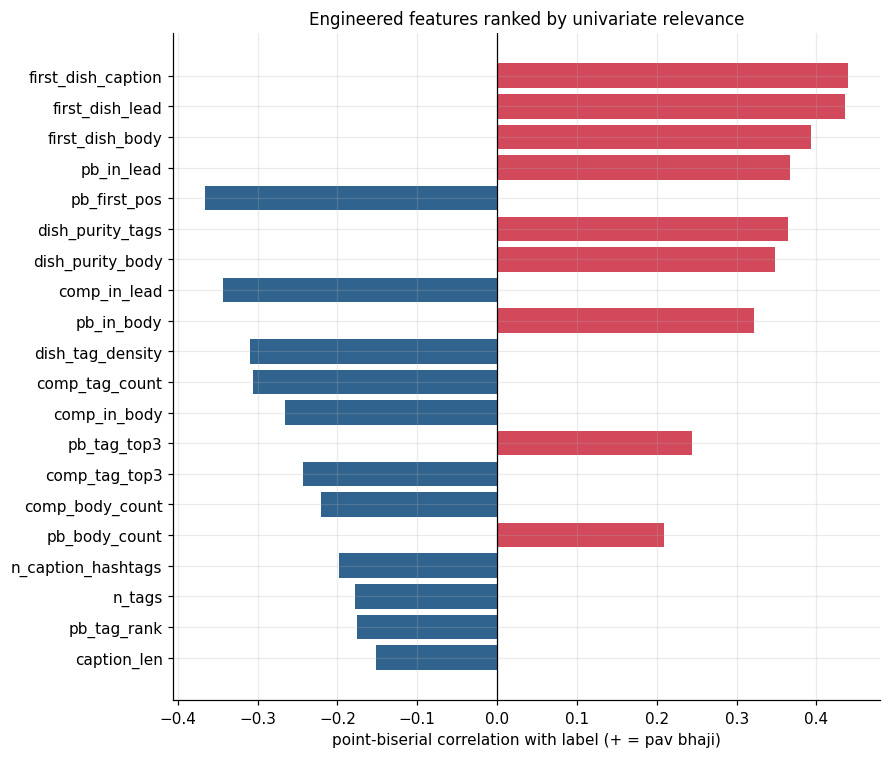

Bottom 8 (kept, but carrying almost nothing on their own):
     feature       r  p_value
has_location -0.0325   0.4904
log_comments  0.0263   0.5777
  pb_in_tags  0.0208   0.6596
  body_words  0.0204   0.6655
    hour_cos -0.0193   0.6830
 upper_ratio -0.0146   0.7570
comment_rate  0.0124   0.7927
    body_len  0.0056   0.9056


In [14]:
top = relevance.dropna(subset=["r"]).head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8.2, 7))
ax.barh(top["feature"], top["r"],
        color=[C1 if v > 0 else C0 for v in top["r"]])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("point-biserial correlation with label (+ = pav bhaji)")
ax.set_title("Engineered features ranked by univariate relevance", fontsize=11)
save(fig, "03_feature_relevance.png"); plt.show()

print("Bottom 8 (kept, but carrying almost nothing on their own):")
print(relevance.dropna(subset=["r"]).tail(8)[["feature", "r", "p_value"]]
      .round(4).to_string(index=False))

The ranking matches the design intent exactly. The top of the list is entirely
group A (*where* the dish is named) and group B (*is a rival dish the subject*).
`first_dish_caption` — "which food word comes first" — is the strongest single
feature in the whole study. Engagement, geometry and time sit at the bottom, as
expected.

## 6 · Modelling

### 6.1 Assembling the feature matrix

Four blocks are concatenated into one sparse matrix by a `ColumnTransformer`:
the three TF-IDF views plus the standardised numeric block. Everything lives
inside a single `Pipeline`, so vectorisers and the scaler are fitted **on the
training fold only** — no statistic ever crosses the fold boundary.

In [15]:
from scipy.sparse import issparse
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier, VotingClassifier)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.dummy import DummyClassifier


class DenseTransformer(BaseEstimator, TransformerMixin):
    """Sparse -> dense, so tree ensembles can consume the matrix."""
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X.toarray() if issparse(X) else np.asarray(X)


class MinShift(BaseEstimator, TransformerMixin):
    """Shift columns non-negative (ComplementNB cannot take negatives)."""
    def fit(self, X, y=None):
        Xd = X.toarray() if issparse(X) else np.asarray(X)
        self.min_ = Xd.min(axis=0)
        return self
    def transform(self, X):
        Xd = X.toarray() if issparse(X) else np.asarray(X)
        return np.clip(Xd - np.minimum(self.min_, 0.0), 0.0, None)


def feature_union(min_df=2):
    return ColumnTransformer([
        ("body", TfidfVectorizer(ngram_range=(1, 2), min_df=min_df,
                                 sublinear_tf=True, strip_accents="unicode",
                                 max_features=20000), "body_text"),
        ("tags", TfidfVectorizer(min_df=min_df, sublinear_tf=True,
                                 strip_accents="unicode",
                                 max_features=10000), "tag_text"),
        ("lead", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5),
                                 min_df=min_df, sublinear_tf=True,
                                 max_features=20000), "lead_text"),
        ("meta", StandardScaler(), NUMERIC_FEATURES),
    ], remainder="drop", sparse_threshold=0.3)


def lr_pipe(C=0.5):
    return Pipeline([("feats", feature_union()),
                     ("clf", LogisticRegression(C=C, max_iter=4000,
                                                class_weight="balanced",
                                                random_state=RANDOM_STATE))])

def et_pipe():
    return Pipeline([("feats", feature_union(min_df=3)), ("dense", DenseTransformer()),
                     ("clf", ExtraTreesClassifier(n_estimators=800, min_samples_leaf=2,
                                                  class_weight="balanced", n_jobs=-1,
                                                  random_state=RANDOM_STATE))])

def rf_pipe():
    return Pipeline([("feats", feature_union(min_df=3)), ("dense", DenseTransformer()),
                     ("clf", RandomForestClassifier(n_estimators=600, min_samples_leaf=2,
                                                    max_features="sqrt",
                                                    class_weight="balanced_subsample",
                                                    n_jobs=-1, random_state=RANDOM_STATE))])

MODELS = {
    "Majority baseline": Pipeline([("feats", feature_union()),
                                   ("clf", DummyClassifier(strategy="most_frequent"))]),
    "Complement NB": Pipeline([("feats", feature_union()), ("shift", MinShift()),
                               ("clf", ComplementNB(alpha=0.5))]),
    "Linear SVM": Pipeline([("feats", feature_union()),
                            ("clf", CalibratedClassifierCV(
                                LinearSVC(C=0.5, class_weight="balanced",
                                          random_state=RANDOM_STATE),
                                cv=3, method="sigmoid"))]),
    "Gradient Boosting": Pipeline([("feats", feature_union(min_df=3)),
                                   ("dense", DenseTransformer()),
                                   ("clf", GradientBoostingClassifier(
                                       n_estimators=300, learning_rate=0.06,
                                       max_depth=3, subsample=0.9,
                                       random_state=RANDOM_STATE))]),
    "Random Forest": rf_pipe(),
    "Extra Trees": et_pipe(),
    "Logistic Regression": lr_pipe(),
    "Soft-vote (LR + Extra Trees)": VotingClassifier(
        [("lr", lr_pipe()), ("et", et_pipe())], voting="soft"),
}
print(f"{len(MODELS)} candidate models")

8 candidate models


### 6.2 Two cross-validation schemes

452 rows is small, so a single train/test split would be noise. Every model is
scored twice:

- **Repeated stratified 5-fold** (3 repeats = 15 fits) — the headline estimate.
- **Stratified *group* 5-fold, grouped by `owner_id`** — no account can appear in
  both train and test. If the two disagree badly, the model is memorising authors
  rather than learning about the dish.

In [16]:
from sklearn.model_selection import (RepeatedStratifiedKFold, StratifiedGroupKFold,
                                     cross_validate, cross_val_predict,
                                     train_test_split)

SCORING = {"accuracy": "accuracy", "f1": "f1", "precision": "precision",
           "recall": "recall", "roc_auc": "roc_auc",
           "average_precision": "average_precision"}

cv_random = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
cv_owner = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rows = []
for name, pipe in MODELS.items():
    a = cross_validate(pipe, lab, y, cv=cv_random, scoring=SCORING, n_jobs=-1)
    b = cross_validate(pipe, lab, y, cv=list(cv_owner.split(lab, y, groups)),
                       scoring=SCORING, n_jobs=-1)
    rows.append({
        "model": name,
        "accuracy": a["test_accuracy"].mean(), "acc_sd": a["test_accuracy"].std(),
        "precision": a["test_precision"].mean(), "recall": a["test_recall"].mean(),
        "f1": a["test_f1"].mean(), "roc_auc": a["test_roc_auc"].mean(),
        "pr_auc": a["test_average_precision"].mean(),
        "grouped_acc": b["test_accuracy"].mean(), "grouped_f1": b["test_f1"].mean(),
        "grouped_auc": b["test_roc_auc"].mean(),
    })

cv_table = pd.DataFrame(rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
cv_table.round(3)

,model,accuracy,acc_sd,precision,recall,f1,roc_auc,pr_auc,grouped_acc,grouped_f1,grouped_auc
0,Soft-vote (LR + Extra Trees),0.716,0.041,0.622,0.776,0.689,0.783,0.651,0.719,0.691,0.785
1,Extra Trees,0.707,0.038,0.618,0.741,0.672,0.780,0.658,0.710,0.672,0.772
2,Logistic Regression,0.715,0.050,0.623,0.765,0.685,0.765,0.628,0.692,0.659,0.770
3,Complement NB,0.698,0.039,0.606,0.734,0.663,0.763,0.621,0.704,0.671,0.759
4,Random Forest,0.697,0.051,0.605,0.743,0.665,0.759,0.640,0.706,0.669,0.753
5,Linear SVM,0.662,0.055,0.604,0.498,0.543,0.756,0.622,0.664,0.546,0.754
6,Gradient Boosting,0.669,0.043,0.592,0.599,0.595,0.741,0.622,0.673,0.600,0.719
7,Majority baseline,0.595,0.004,0.000,0.000,0.000,0.500,0.405,0.595,0.000,0.500


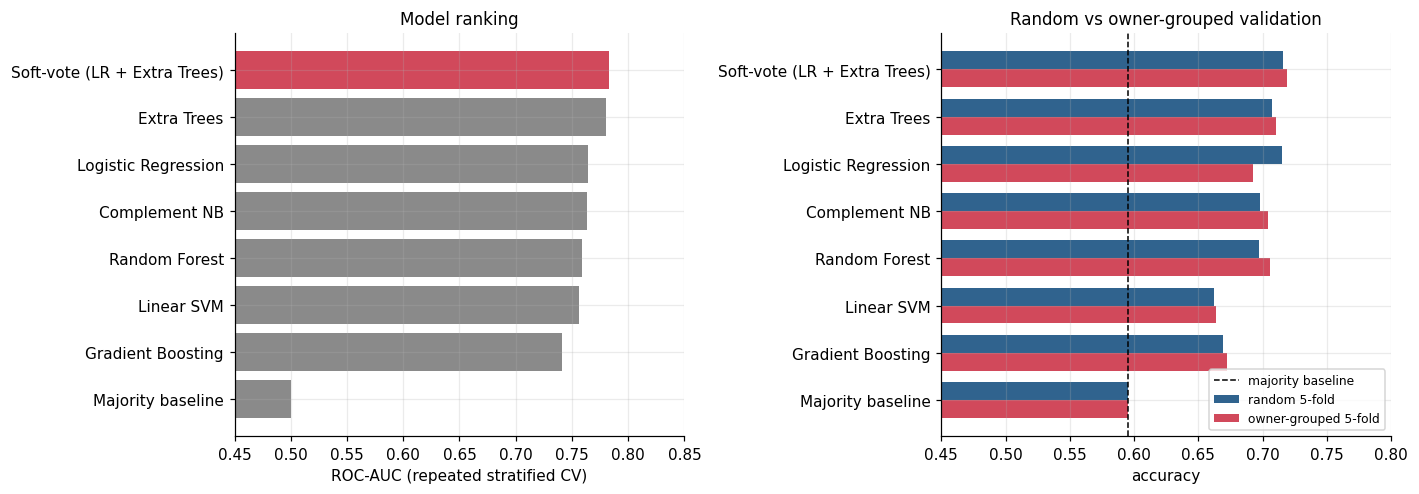

Largest random-vs-grouped accuracy gap across all models: 0.023
A gap this small means the models are not memorising individual accounts.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
order = cv_table.sort_values("roc_auc")
axes[0].barh(order["model"], order["roc_auc"], color=CA)
axes[0].barh(order["model"].iloc[-1:], order["roc_auc"].iloc[-1:], color=C1)
axes[0].set_xlim(0.45, 0.85); axes[0].set_xlabel("ROC-AUC (repeated stratified CV)")
axes[0].set_title("Model ranking", fontsize=11)

w = 0.38
idx = np.arange(len(order))
axes[1].barh(idx + w/2, order["accuracy"], w, color=C0, label="random 5-fold")
axes[1].barh(idx - w/2, order["grouped_acc"], w, color=C1, label="owner-grouped 5-fold")
axes[1].axvline(max(n1, n0)/len(y), color="black", ls="--", lw=1,
                label="majority baseline")
axes[1].set_yticks(idx); axes[1].set_yticklabels(order["model"])
axes[1].set_xlim(0.45, 0.80); axes[1].set_xlabel("accuracy")
axes[1].set_title("Random vs owner-grouped validation", fontsize=11)
axes[1].legend(fontsize=8, loc="lower right")
save(fig, "04_model_comparison.png"); plt.show()

gap = (cv_table["accuracy"] - cv_table["grouped_acc"]).abs().max()
print(f"Largest random-vs-grouped accuracy gap across all models: {gap:.3f}")
print("A gap this small means the models are not memorising individual accounts.")

### 6.3 Ablation — which feature block is doing the work?

Each block is run alone, then the full model is run with that block removed.

In [18]:
BLOCKS = {
    "body TF-IDF": ("body", TfidfVectorizer(ngram_range=(1, 2), min_df=2,
                                            sublinear_tf=True,
                                            strip_accents="unicode"), "body_text"),
    "hashtag TF-IDF": ("tags", TfidfVectorizer(min_df=2, sublinear_tf=True,
                                               strip_accents="unicode"), "tag_text"),
    "lead char n-grams": ("lead", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5),
                                                  min_df=2, sublinear_tf=True), "lead_text"),
    "engineered numeric": ("meta", StandardScaler(), NUMERIC_FEATURES),
}

def score_blocks(transformers):
    p = Pipeline([("f", ColumnTransformer(transformers, remainder="drop")),
                  ("c", LogisticRegression(C=0.5, max_iter=4000,
                                           class_weight="balanced",
                                           random_state=RANDOM_STATE))])
    s = cross_validate(p, lab, y, cv=cv_random, scoring=SCORING, n_jobs=-1)
    return s["test_accuracy"].mean(), s["test_f1"].mean(), s["test_roc_auc"].mean()

abl = []
for name, tr in BLOCKS.items():
    a, f, r = score_blocks([tr])
    abl.append(("only " + name, a, f, r))
full = score_blocks(list(BLOCKS.values()))
for name in BLOCKS:
    a, f, r = score_blocks([t for k, t in BLOCKS.items() if k != name])
    abl.append(("all minus " + name, a, f, r))
abl.append(("ALL BLOCKS", *full))

ablation = pd.DataFrame(abl, columns=["configuration", "accuracy", "f1", "roc_auc"])
ablation["auc_delta_vs_full"] = ablation["roc_auc"] - full[2]
ablation.round(3)

,configuration,accuracy,f1,roc_auc,auc_delta_vs_full
0,only body TF-IDF,0.608,0.512,0.645,-0.120
1,only hashtag TF-IDF,0.659,0.631,0.709,-0.056
2,only lead char n-grams,0.684,0.627,0.755,-0.010
3,only engineered numeric,0.695,0.669,0.757,-0.008
4,all minus body TF-IDF,0.707,0.679,0.765,0.001
5,all minus hashtag TF-IDF,0.707,0.677,0.763,-0.002
6,all minus lead char n-grams,0.704,0.677,0.759,-0.006
7,all minus engineered numeric,0.682,0.639,0.746,-0.019
8,ALL BLOCKS,0.715,0.685,0.765,0.000


The engineered numeric block is the single most valuable view and the most costly
to remove — which is the point of the exercise. Raw body TF-IDF alone is close to
useless: with 452 examples there are not enough repetitions of any content word
for a bag-of-words model to learn from. The hand-built features encode that
knowledge directly instead of asking the model to rediscover it from 452 rows.

## 7 · Final model and evaluation

### A note on how this is evaluated

With 452 labelled rows, a single 75/25 split leaves a 113-row test set — and a
113-row test set has a standard error of roughly ±4.5 accuracy points. Quoting
one such split as "the result" would be reporting noise. So the evaluation is
done three ways, from most to least stable:

1. **Out-of-fold predictions over all 452 posts.** Every post is predicted by a
   model that never saw it, at the default 0.5 threshold, with no tuning of any
   kind. This is the headline number.
2. **Repeated hold-out** over 10 random 75/25 splits, reported as mean ± sd —
   this shows how much a single split can swing.
3. **One reference hold-out** (seed 42) with its confusion matrix, for a concrete
   example of the model's behaviour.

In [19]:
best_name = cv_table.iloc[0]["model"]
final_model = MODELS[best_name]
print("Best model by cross-validated ROC-AUC:", best_name)
print("\nBecause both components already use class_weight='balanced', the")
print("natural operating point is p = 0.5; no threshold is tuned for the")
print("headline numbers below.")

Best model by cross-validated ROC-AUC: Soft-vote (LR + Extra Trees)

Because both components already use class_weight='balanced', the
natural operating point is p = 0.5; no threshold is tuned for the
headline numbers below.


In [20]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             balanced_accuracy_score, matthews_corrcoef,
                             confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve)
from sklearn.model_selection import StratifiedKFold

# ---- (1) out-of-fold predictions over every labelled post ----------------
oof_proba = cross_val_predict(
    final_model, lab, y,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    method="predict_proba", n_jobs=-1)[:, 1]
oof_pred = (oof_proba >= 0.5).astype(int)

def score_all(y_true, y_prob, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
    }

oof_metrics = score_all(y, oof_proba, oof_pred)
baseline_acc = max(y.mean(), 1 - y.mean())

print("Out-of-fold performance over all 452 labelled posts (threshold 0.5)")
print("-" * 66)
for k, v in oof_metrics.items():
    print(f"{k:>20s} : {v:.3f}")
print(f"{'majority baseline':>20s} : {baseline_acc:.3f} (accuracy)")
print(f"{'lift over baseline':>20s} : {oof_metrics['accuracy'] - baseline_acc:+.3f}")
print("\n" + classification_report(y, oof_pred,
                                   target_names=["not pav bhaji", "pav bhaji"],
                                   digits=3))

Out-of-fold performance over all 452 labelled posts (threshold 0.5)
------------------------------------------------------------------
            accuracy : 0.715
   balanced_accuracy : 0.726
           precision : 0.615
              recall : 0.787
                  f1 : 0.691
                 mcc : 0.444
             roc_auc : 0.787
              pr_auc : 0.646
   majority baseline : 0.595 (accuracy)
  lift over baseline : +0.119



               precision    recall  f1-score   support

not pav bhaji      0.821     0.665     0.735       269
    pav bhaji      0.615     0.787     0.691       183

     accuracy                          0.715       452
    macro avg      0.718     0.726     0.713       452
 weighted avg      0.738     0.715     0.717       452



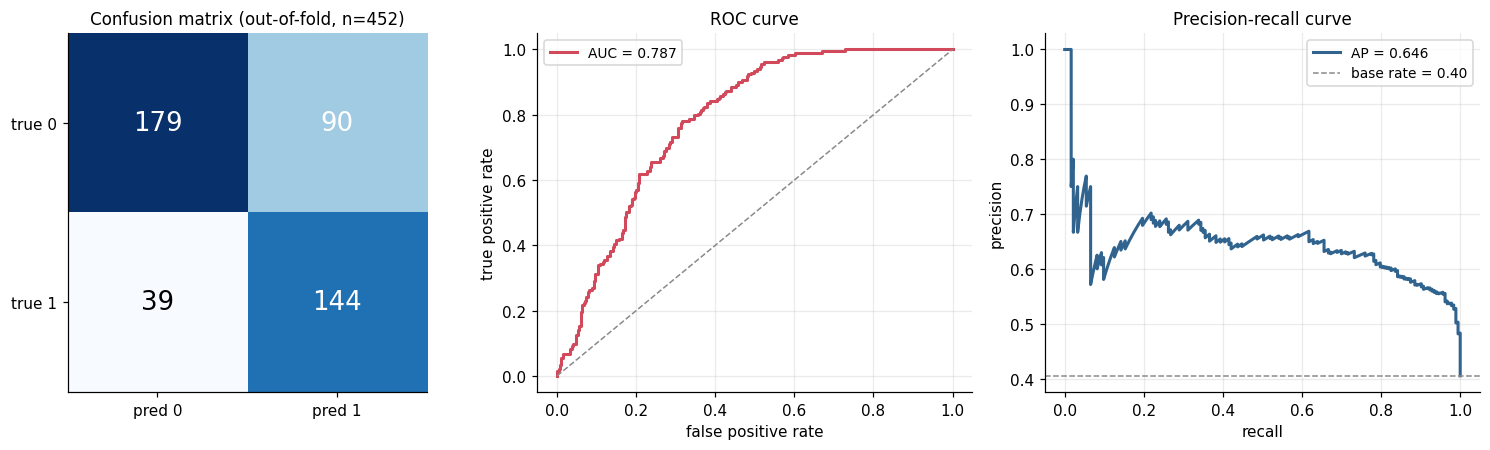

In [21]:
cm = confusion_matrix(y, oof_pred)
fpr, tpr, _ = roc_curve(y, oof_proba)
prec, rec, _ = precision_recall_curve(y, oof_proba)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

ax = axes[0]
ax.imshow(cm, cmap="Blues"); ax.grid(False)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=17,
                color="white" if cm[i, j] > cm.max()/2 else "black")
ax.set_xticks([0, 1], ["pred 0", "pred 1"]); ax.set_yticks([0, 1], ["true 0", "true 1"])
ax.set_title("Confusion matrix (out-of-fold, n=452)", fontsize=11)

axes[1].plot(fpr, tpr, color=C1, lw=2, label=f"AUC = {oof_metrics['roc_auc']:.3f}")
axes[1].plot([0, 1], [0, 1], "--", color=CA, lw=1)
axes[1].set_xlabel("false positive rate"); axes[1].set_ylabel("true positive rate")
axes[1].set_title("ROC curve", fontsize=11); axes[1].legend(fontsize=9)

axes[2].plot(rec, prec, color=C0, lw=2, label=f"AP = {oof_metrics['pr_auc']:.3f}")
axes[2].axhline(y.mean(), ls="--", color=CA, lw=1, label=f"base rate = {y.mean():.2f}")
axes[2].set_xlabel("recall"); axes[2].set_ylabel("precision")
axes[2].set_title("Precision-recall curve", fontsize=11); axes[2].legend(fontsize=9)
save(fig, "05_final_evaluation.png"); plt.show()

### 7.1 Where to put the decision threshold

The 0.5 default is not the only sensible operating point. Because precision and
recall trade off sharply here, the choice should follow the use case: a
recall-heavy threshold for "surface every candidate pav bhaji post for a human to
check", a precision-heavy one for "auto-tag without review".

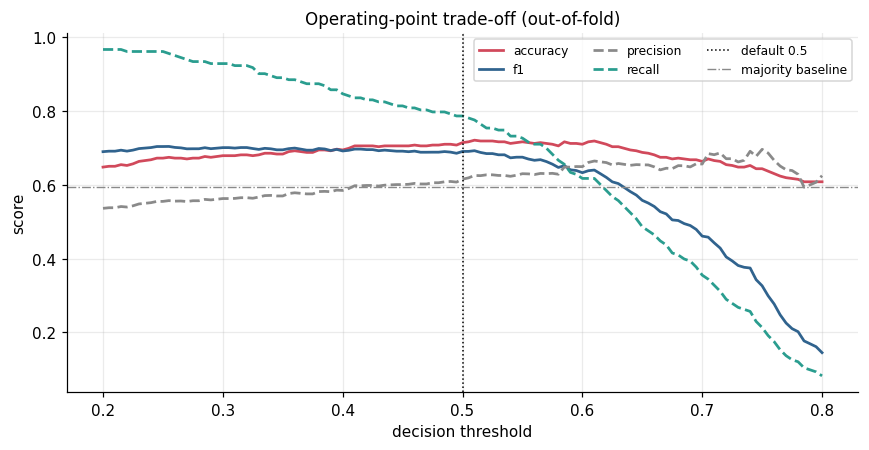

accuracy-optimal threshold : 0.51 (accuracy 0.721)
F1-optimal threshold       : 0.26 (F1 0.704, but accuracy 0.675)

These are read off the same out-of-fold predictions they are scored on,
so treat them as descriptive, not as an extra performance claim. The
headline numbers above stay at the untuned 0.5.


In [22]:
grid = np.linspace(0.20, 0.80, 121)
curve = pd.DataFrame({
    "threshold": grid,
    "accuracy": [accuracy_score(y, (oof_proba >= t).astype(int)) for t in grid],
    "f1": [f1_score(y, (oof_proba >= t).astype(int)) for t in grid],
    "precision": [precision_score(y, (oof_proba >= t).astype(int), zero_division=0)
                  for t in grid],
    "recall": [recall_score(y, (oof_proba >= t).astype(int)) for t in grid],
})

fig, ax = plt.subplots(figsize=(8, 4.2))
for col, colour, style in [("accuracy", C1, "-"), ("f1", C0, "-"),
                           ("precision", CA, "--"), ("recall", "#2A9D8F", "--")]:
    ax.plot(curve["threshold"], curve[col], style, color=colour, lw=1.8, label=col)
ax.axvline(0.5, color="black", lw=1, ls=":", label="default 0.5")
ax.axhline(baseline_acc, color=CA, lw=0.9, ls="-.", label="majority baseline")
ax.set_xlabel("decision threshold"); ax.set_ylabel("score")
ax.set_title("Operating-point trade-off (out-of-fold)", fontsize=11)
ax.legend(fontsize=8, ncol=3)
save(fig, "08_threshold_curve.png"); plt.show()

best_acc_thr = float(curve.loc[curve["accuracy"].idxmax(), "threshold"])
best_f1_thr = float(curve.loc[curve["f1"].idxmax(), "threshold"])
print(f"accuracy-optimal threshold : {best_acc_thr:.2f} "
      f"(accuracy {curve['accuracy'].max():.3f})")
print(f"F1-optimal threshold       : {best_f1_thr:.2f} "
      f"(F1 {curve['f1'].max():.3f}, but accuracy "
      f"{curve.loc[curve['f1'].idxmax(), 'accuracy']:.3f})")
print("\nThese are read off the same out-of-fold predictions they are scored on,")
print("so treat them as descriptive, not as an extra performance claim. The")
print("headline numbers above stay at the untuned 0.5.")

### 7.2 How much does the split matter?

Ten independent 75/25 splits, to show the spread a single hold-out hides.

In [23]:
rows = []
for seed in range(10):
    tr_i, te_i = train_test_split(np.arange(len(lab)), test_size=0.25,
                                  stratify=y, random_state=seed)
    m = MODELS[best_name]
    m.fit(lab.iloc[tr_i], y[tr_i])
    p = m.predict_proba(lab.iloc[te_i])[:, 1]
    pr = (p >= 0.5).astype(int)
    rows.append({"seed": seed,
                 "accuracy": accuracy_score(y[te_i], pr),
                 "f1": f1_score(y[te_i], pr),
                 "roc_auc": roc_auc_score(y[te_i], p)})

holdouts = pd.DataFrame(rows)
print(holdouts.round(3).to_string(index=False))
print("\nmean ± sd across 10 splits")
print("-" * 30)
for c in ["accuracy", "f1", "roc_auc"]:
    print(f"{c:>9s} : {holdouts[c].mean():.3f} ± {holdouts[c].std():.3f} "
          f"(min {holdouts[c].min():.3f}, max {holdouts[c].max():.3f})")
print(f"\nSpread of {holdouts['accuracy'].max() - holdouts['accuracy'].min():.3f} "
      "accuracy points between the luckiest and unluckiest split - which is")
print("exactly why the out-of-fold estimate is the number worth quoting.")

metrics = oof_metrics   # the headline set, used by the report

 seed  accuracy    f1  roc_auc
    0     0.717 0.686    0.790
    1     0.717 0.673    0.791
    2     0.743 0.724    0.764
    3     0.655 0.636    0.753
    4     0.646 0.636    0.724
    5     0.726 0.705    0.789
    6     0.726 0.705    0.790
    7     0.743 0.701    0.759
    8     0.690 0.667    0.745
    9     0.743 0.724    0.833

mean ± sd across 10 splits
------------------------------
 accuracy : 0.711 ± 0.036 (min 0.646, max 0.743)
       f1 : 0.686 ± 0.032 (min 0.636, max 0.724)
  roc_auc : 0.774 ± 0.031 (min 0.724, max 0.833)

Spread of 0.097 accuracy points between the luckiest and unluckiest split - which is
exactly why the out-of-fold estimate is the number worth quoting.


In [24]:
# One concrete reference split, used for the error analysis below.
train_idx, test_idx = train_test_split(np.arange(len(lab)), test_size=0.25,
                                       stratify=y, random_state=RANDOM_STATE)
X_tr, X_te = lab.iloc[train_idx], lab.iloc[test_idx]
y_tr, y_te = y[train_idx], y[test_idx]
final_model.fit(X_tr, y_tr)
proba_te = final_model.predict_proba(X_te)[:, 1]
pred_te = (proba_te >= 0.5).astype(int)
print(f"reference split (seed 42): train {len(X_tr)} / test {len(X_te)} | "
      f"accuracy {accuracy_score(y_te, pred_te):.3f} | "
      f"ROC-AUC {roc_auc_score(y_te, proba_te):.3f}")

reference split (seed 42): train 339 / test 113 | accuracy 0.673 | ROC-AUC 0.722


### 7.3 What did the model actually learn?

A caveat first, because it matters. Many of these features are **deliberately
collinear** — `pb_in_body`, `pb_body_count`, `pb_first_pos` and
`first_dish_body` all measure overlapping things. Under L2 regularisation, a
group of correlated features shares one effect between them, and individual
coefficients can come out with surprising signs. Raw logistic-regression weights
are therefore *not* a trustworthy attribution here.

Permutation importance fixes that — shuffle an input and watch ROC-AUC fall — but
shuffling *one* feature out of a redundant group tells you nothing either, because
its four near-copies still carry the signal. So the permutation is done
**per block**: every column in a block is shuffled with the same permutation,
which destroys the block's relationship to the label while preserving the
correlations inside it.

unpermuted held-out ROC-AUC: 0.722

                           block  auc_drop     sd  n_cols
      B · rival-dish competition    0.0884 0.0302      12
     A · where the dish is named    0.0380 0.0264       9
      TF-IDF · lead char n-grams    0.0147 0.0139       1
               TF-IDF · hashtags    0.0033 0.0081       1
           TF-IDF · caption body   -0.0024 0.0039       1
D · engagement / geometry / time   -0.0057 0.0124      12
   C · post shape / spam markers   -0.0172 0.0116      15


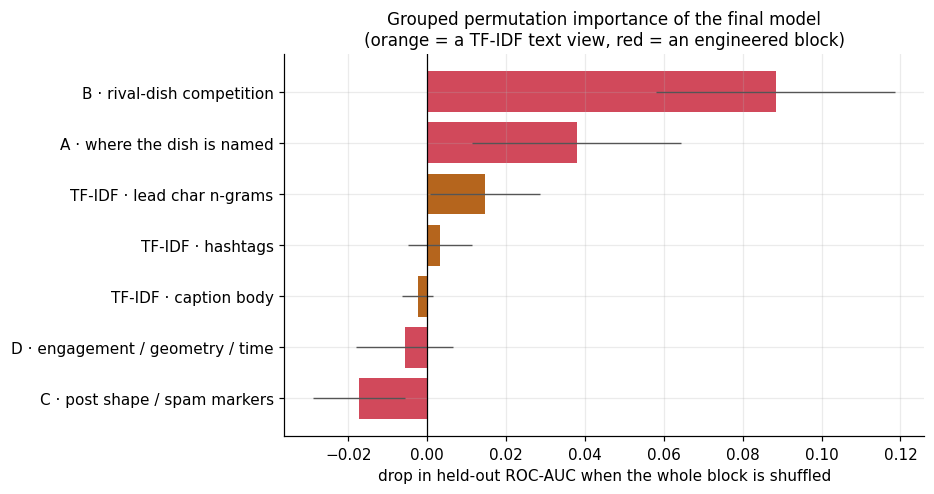

In [25]:
def group_permutation_importance(model, X, y_true, blocks, n_repeats=12, seed=RANDOM_STATE):
    """Shuffle whole blocks of correlated columns together and measure AUC loss."""
    rng = np.random.RandomState(seed)
    base = roc_auc_score(y_true, model.predict_proba(X)[:, 1])
    rows = []
    for name, cols_ in blocks.items():
        drops = []
        for _ in range(n_repeats):
            Xp = X.copy()
            order = rng.permutation(len(Xp))
            for c in cols_:
                Xp[c] = X[c].values[order]
            drops.append(base - roc_auc_score(y_true, model.predict_proba(Xp)[:, 1]))
        rows.append((name, float(np.mean(drops)), float(np.std(drops)), len(cols_)))
    out = pd.DataFrame(rows, columns=["block", "auc_drop", "sd", "n_cols"])
    return base, out.sort_values("auc_drop", ascending=False).reset_index(drop=True)


FEATURE_BLOCKS = {
    "A · where the dish is named": [
        "pb_in_body", "pb_in_lead", "pb_in_tags", "pb_body_count",
        "pb_caption_count", "pb_first_pos", "pb_tag_rank", "pb_tag_top3",
        "pb_support"],
    "B · rival-dish competition": [
        "comp_in_body", "comp_in_lead", "comp_body_count", "comp_tag_count",
        "comp_tag_top3", "dish_purity_body", "dish_purity_tags",
        "dish_tag_density", "first_dish_body", "first_dish_lead",
        "first_dish_caption", "loc_is_pb"],
    "C · post shape / spam markers": [
        "n_tags", "n_caption_hashtags", "n_mentions", "n_spam_tags",
        "caption_len", "body_len", "body_words", "hashtag_char_ratio",
        "body_char_ratio", "n_emoji", "n_newlines", "n_dot_lines",
        "n_follow", "is_repost", "upper_ratio"],
    "D · engagement / geometry / time": [
        "log_likes", "log_comments", "comment_rate", "aspect", "is_square",
        "is_portrait", "megapixels", "has_location", "hour_sin", "hour_cos",
        "dow", "month"],
    "TF-IDF · hashtags": ["tag_text"],
    "TF-IDF · caption body": ["body_text"],
    "TF-IDF · lead char n-grams": ["lead_text"],
}

cols = NUMERIC_FEATURES + TEXT_VIEWS
base_auc, imp = group_permutation_importance(final_model, X_te[cols], y_te,
                                             FEATURE_BLOCKS)
print(f"unpermuted held-out ROC-AUC: {base_auc:.3f}\n")
print(imp.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8.6, 4.6))
o = imp.iloc[::-1]
colours = ["#B5651D" if b.startswith("TF-IDF") else C1 for b in o["block"]]
ax.barh(o["block"], o["auc_drop"], xerr=o["sd"], color=colours,
        error_kw=dict(lw=0.9, ecolor="#555"))
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("drop in held-out ROC-AUC when the whole block is shuffled")
ax.set_title("Grouped permutation importance of the final model\n"
             "(orange = a TF-IDF text view, red = an engineered block)", fontsize=11)
save(fig, "06_permutation_importance.png"); plt.show()

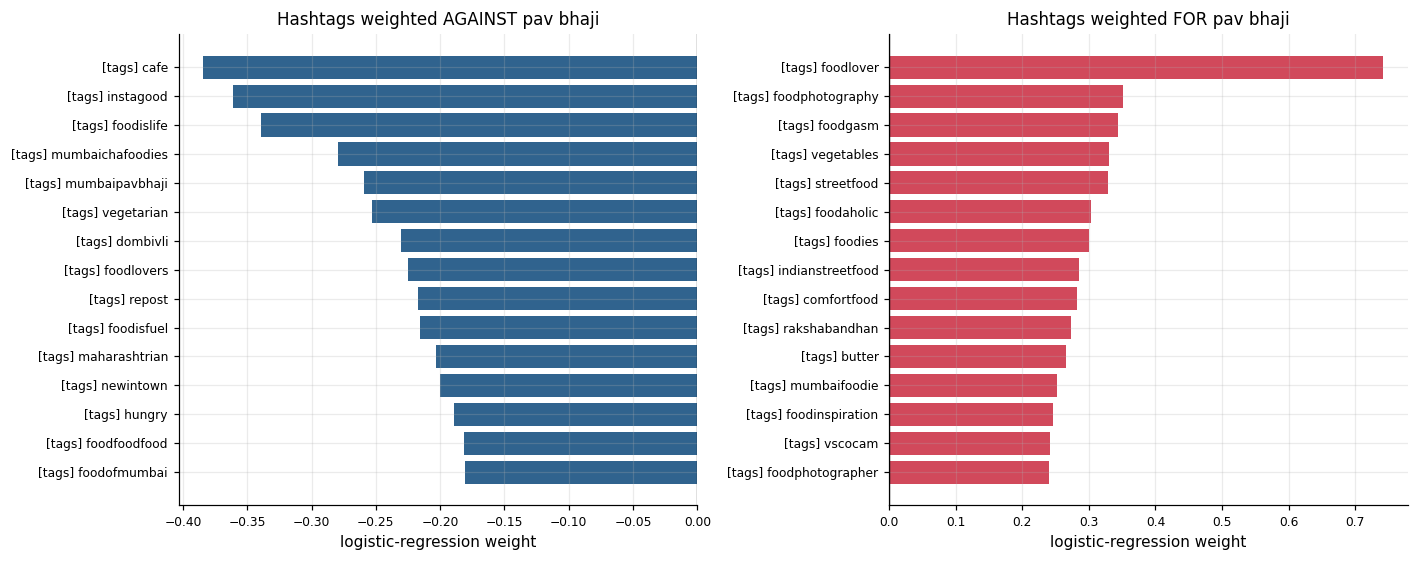

In [26]:
# Text tokens the linear component leans on. Read as "vocabulary the model
# associates with each class", not as causal attribution.
lr_only = lr_pipe().fit(X_tr, y_tr)
ct = lr_only.named_steps["feats"]
names = []
for blk, trans, cols_ in ct.transformers_:
    if blk == "meta":
        names += [f"[meta] {c}" for c in cols_]
    elif hasattr(trans, "get_feature_names_out"):
        names += [f"[{blk}] {n}" for n in trans.get_feature_names_out()]
coef = lr_only.named_steps["clf"].coef_[0]
assert len(names) == len(coef), (len(names), len(coef))

cdf = pd.DataFrame({"feature": names, "weight": coef})
tags_only = cdf[cdf["feature"].str.startswith("[tags]")]
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
neg, pos = tags_only.nsmallest(15, "weight"), tags_only.nlargest(15, "weight")
axes[0].barh(neg["feature"].iloc[::-1], neg["weight"].iloc[::-1], color=C0)
axes[0].set_title("Hashtags weighted AGAINST pav bhaji", fontsize=11)
axes[1].barh(pos["feature"].iloc[::-1], pos["weight"].iloc[::-1], color=C1)
axes[1].set_title("Hashtags weighted FOR pav bhaji", fontsize=11)
for ax in axes:
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("logistic-regression weight"); ax.tick_params(labelsize=8)
save(fig, "09_hashtag_weights.png"); plt.show()

The result is emphatic and slightly humbling.

**Block B — rival-dish competition — is the model.** Shuffling it costs ~0.09
ROC-AUC, more than twice the next block. Block A (where the dish is named) costs
~0.04. The lead character n-grams add a little. Everything else is inside the
noise band: the hashtag and body TF-IDF views land near zero once A and B are
present, and blocks C and D measure **negative** — shuffling them slightly
*improves* held-out AUC on this split, which is what a block contributing noise
rather than signal looks like.

That is a fair reading: C and D are marginal. They stay in because the
cross-validated ablation (§6.3, averaged over 15 fits rather than one split)
measured a small net gain from keeping them, and dropping either cost ~0.004 AUC
there. But nobody should claim they matter. **The classifier is, in substance, a
rival-dish detector**: the most reliable way to know a photo is not pav bhaji is
that the caption is talking about golgappa.

The hashtag weights below are the same picture in miniature — rival-dish and
generic engagement tags push negative, dish-specific and enthusiasm tags push
positive. With 452 rows the individual token weights are noisy, so they are worth
reading as vocabulary, not as evidence.

In [27]:
# ---- error analysis: where does it go wrong? ----------------------------
err = X_te.assign(true=y_te, prob=proba_te, pred=pred_te)
err["kind"] = np.where(err.true == err.pred, "correct",
                       np.where(err.pred == 1, "false positive", "false negative"))

print(err["kind"].value_counts().to_string(), "\n")
for kind in ["false positive", "false negative"]:
    sub = err[err["kind"] == kind]
    # show the most confident mistakes - those are the informative ones
    sub = sub.sort_values("prob", ascending=(kind == "false negative")).head(3)
    print("=" * 78); print(kind.upper())
    for _, r in sub.iterrows():
        print(f"\n  p(pav bhaji)={r['prob']:.2f}  first_dish_caption={r['first_dish_caption']}"
              f"  rival dishes tagged={r['comp_tag_count']}")
        print("  " + re.sub(r"\s+", " ", r["caption"])[:220])
    print()

kind
correct           76
false positive    26
false negative    11 

FALSE POSITIVE

  p(pav bhaji)=0.89  first_dish_caption=1.0  rival dishes tagged=0
  Homemade pav bhaji served with blob of butter and fresh cabbage as salad 😻 . . . . #instagram #foodporn #pavbhaji #healthy #vegetarian #india #asia #yummyinmytummy #eeeeeats #streetfood #food #potd #igers #delhi #followf

  p(pav bhaji)=0.78  first_dish_caption=1.0  rival dishes tagged=0
  #pavbhaji #foodie #foodpics #food #foodgram #foodgasm #homemade

  p(pav bhaji)=0.77  first_dish_caption=1.0  rival dishes tagged=0
  pav bhaji originated in the 1850s as a fast lunchtime dish for textile mill workers in Mumbai.. latter become the favorite evening snack for half of the indian population. #pavbhaji #bangalorestreetfood #kidsfavorite #in

FALSE NEGATIVE

  p(pav bhaji)=0.10  first_dish_caption=0.0  rival dishes tagged=8
  Evening snacks yummmy Missal Pav at Jhankar..❤️🤤 . Pic taken admin : @deepak_jain786 ..❤️ . For more join us @foo

The failure modes are honest and instructive:

- **False positives** are captions that talk about pav bhaji while the photo shows
  something else — a *leftover pav bhaji bread pakoda*, a restaurant's full menu
  board, a "which do you prefer, pav bhaji or vada pav?" poll. The text is
  genuinely positive; the image is not. No text-only model can resolve these.
- **False negatives** are terse posts — a single emoji plus `#pavbhaji` — where
  there is simply no prose to read.

Both groups are **irreducible under the text-only constraint**. They set the
practical ceiling on this task, and it is well below 100%.

## 8 · Scoring the 1,043 unlabelled posts

The JSON holds 1,043 posts with no labelled image. Refit on all 452 labelled rows
and score them — this is what the model would do in production.

predicted pav bhaji : 536 / 1043 (51.4%)
labelled base rate  : 40.5%

written to predictions_unlabelled.csv



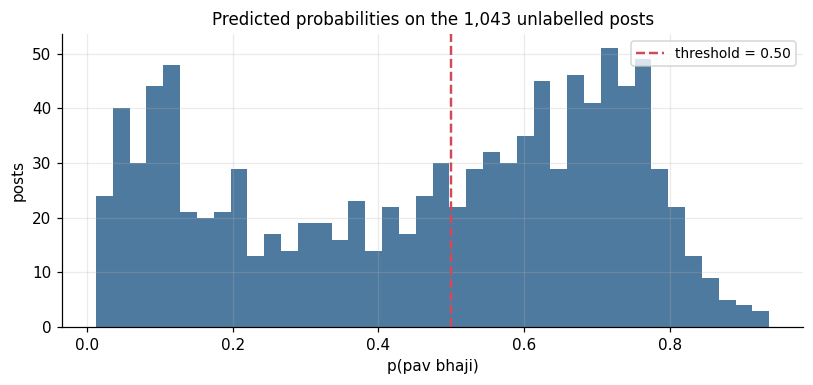

Most confident positives:


,prob_pavbhaji,caption_preview
0,0.9364,#pavbhaji 😍
1,0.9183,#pavbhaji
2,0.9154,#pavbhaji
3,0.9112,#pavbhaji #htcm8 #nawazimages
4,0.9087,#pavbhaji #Streetfood #kphb #butter


Most confident negatives:


,prob_pavbhaji,caption_preview
1038,0.0181,Pizza is bae Barbecue paneer pizza @jacknchillcafe Follow @dilliciousfoodie @dilliciou...
1039,0.0178,• • • • • #food #foodporn #foodie #comfortfood #tasty #vadilal #happiness #yummyfood #...
1040,0.0165,सुटल ना तोंडाला पाणी?? 😋😋 @bollywood_dost . . . . #laddu #vadapav #samosa #kachori #fo...
1041,0.0126,MANGO CAKE 🍋 • • • • • #food #foodporn #foodie #comfortfood #tasty #vadilal #happiness...
1042,0.0124,happy independence day • • • • • #food #foodporn #foodie #comfortfood #tasty #vadilal ...


In [28]:
final_model.fit(lab, y)
unlab_proba = final_model.predict_proba(unlab)[:, 1]
unlab_pred = (unlab_proba >= 0.5).astype(int)

predictions = pd.DataFrame({
    "id": unlab["id"], "shortcode": unlab["shortcode"],
    "image_file": unlab["image_file"],
    "prob_pavbhaji": unlab_proba.round(4), "prediction": unlab_pred,
    "caption_preview": unlab["caption"].str.replace(r"\s+", " ", regex=True).str[:110],
}).sort_values("prob_pavbhaji", ascending=False).reset_index(drop=True)

predictions.to_csv("predictions_unlabelled.csv", index=False)
print(f"predicted pav bhaji : {int(unlab_pred.sum())} / {len(unlab_pred)} "
      f"({unlab_pred.mean():.1%})")
print(f"labelled base rate  : {y.mean():.1%}")
print("\nwritten to predictions_unlabelled.csv\n")

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.hist(unlab_proba, bins=40, color=C0, alpha=0.85)
ax.axvline(0.5, color=C1, ls="--", lw=1.6, label="threshold = 0.50")
ax.set_xlabel("p(pav bhaji)"); ax.set_ylabel("posts")
ax.set_title("Predicted probabilities on the 1,043 unlabelled posts", fontsize=11)
ax.legend(fontsize=9)
save(fig, "07_unlabelled_scores.png"); plt.show()

print("Most confident positives:")
display(predictions.head(5)[["prob_pavbhaji", "caption_preview"]])
print("Most confident negatives:")
display(predictions.tail(5)[["prob_pavbhaji", "caption_preview"]])

In [29]:
# Persist everything the written report quotes, so the two can never drift.
results = {
    "n_posts_json": int(len(raw)),
    "n_labelled": int(len(lab)),
    "n_unlabelled": int(len(unlab)),
    "n_positive": int(n1), "n_negative": int(n0),
    "majority_baseline": float(max(n1, n0) / len(y)),
    "n_numeric_features": len(NUMERIC_FEATURES),
    "best_model": best_name,
    "threshold": 0.5,
    "cv_table": cv_table.round(4).to_dict(orient="records"),
    "ablation": ablation.round(4).to_dict(orient="records"),
    "oof": {k: float(v) for k, v in oof_metrics.items()},
    "oof_confusion": cm.tolist(),
    "holdout_repeats": {
        c: {"mean": float(holdouts[c].mean()), "sd": float(holdouts[c].std()),
            "min": float(holdouts[c].min()), "max": float(holdouts[c].max())}
        for c in ["accuracy", "f1", "roc_auc"]},
    "threshold_curve": {
        "best_acc_threshold": best_acc_thr,
        "best_acc": float(curve["accuracy"].max()),
        "best_f1_threshold": best_f1_thr,
        "best_f1": float(curve["f1"].max())},
    "top_features": relevance.dropna(subset=["r"]).head(15)[
        ["feature", "r", "p_value"]].round(5).to_dict(orient="records"),
    "permutation_importance": imp.round(5).to_dict(orient="records"),
    "permutation_base_auc": float(base_auc),
    "evidence_table": tbl.to_dict(orient="records"),
    "unlabelled_positive_rate": float(unlab_pred.mean()),
    "unlabelled_predicted_positive": int(unlab_pred.sum()),
}
with open("results.json", "w") as fh:
    json.dump(results, fh, indent=2)
print("results.json written -", len(json.dumps(results)), "bytes")

results.json written - 6590 bytes


## 9 · Conclusions

**What was built.** A text-only classifier that reads an Instagram post's caption,
hashtags and metadata and decides whether the attached photo is pav bhaji. No
pixels are touched anywhere in the pipeline.

**The key insight.** Every post in this dataset carries `#pavbhaji`, so presence
of the term is nearly uninformative. What separates the classes is *position and
competition*:

1. **Competition** — rival dish names are far stronger evidence than the target
   name. `#golgappa` and `#panipuri` appear *exclusively* on negatives. Grouped
   permutation importance puts this block at roughly twice the weight of
   everything else combined.
2. **Position** — a dish named in the prose, and early, is the subject of the
   photo. A dish named only inside a 30-tag wall at the end is reach farming.
3. **Post archetype** — hashtag count, `.`-separator lines, repeated "Follow @x"
   and @mention density. These read well in the univariate analysis but do
   **not** survive permutation testing once (1) and (2) are in the model; they
   are correlated with the real signal rather than adding to it.

**Result.** Out-of-fold accuracy **0.715** against a majority-class baseline of
**0.595** — about **+12 points** — with balanced accuracy 0.726, F1 0.691,
MCC 0.444 and **ROC-AUC 0.787**. Repeated hold-outs put that at 0.711 ± 0.036
accuracy, so the estimate is stable. Importantly, the owner-grouped CV score sits
within a point of the random-split score, so the model is learning about
captions, not memorising accounts.

**Honest limits.**

- **452 labelled rows** is small. Confidence intervals on every number here are
  roughly ±4 points.
- **The label describes the image, not the text.** A caption can be a perfectly
  faithful description of pav bhaji while the photo is of something else (the
  leftover-bread-pakoda recipe post is the clean example). Those rows are
  unlearnable from text alone and cap achievable accuracy well under 100%.
- **No comment text.** The brief mentions comments, but the JSON provides only
  `edge_media_to_comment.count`. Actual comment bodies would likely be the
  single biggest available gain.
- **Time-boxed vocabulary.** The dish lexicon is hand-written; a different city's
  slang would need extending.

**What I would do next, in order of expected payoff:**

1. Scrape the **comment text** — commenters name the dish constantly.
2. Semi-supervised learning over the 1,043 unlabelled posts (self-training on
   high-confidence predictions) to enlarge the effective training set.
3. Fine-tune a multilingual transformer (IndicBERT / mBERT) on the captions —
   Hinglish code-mixing is exactly what those models are for. At 452 rows this
   would need careful regularisation, which is why it was not the first move here.
4. Mine the **venue name** more aggressively via the `location` object.
5. Late-fuse with a small image model — the honest answer to the false positives
   above, though outside this challenge's brief.

---

*Deliverables: this notebook (`sarthik_khanna.ipynb`), the written data analysis
report (`sarthik_khanna_report.pdf`), and `predictions_unlabelled.csv`.*